# 🪑 Sitting Posture Detection — YOLO26

Notebook ini melatih model **YOLO26** untuk mendeteksi & mengklasifikasikan postur duduk seseorang sebagai **benar** atau **tidak benar**, lalu memberikan **peringatan (warning)** secara real-time.

**Dataset:** [Sitting Posture – Roboflow Universe](https://universe.roboflow.com/dataset-sqm0h/sitting-posture-ezkda)

---
### 📋 Alur Notebook
1. Setup environment & install dependencies
2. Download dataset dari Roboflow
3. Eksplorasi dataset + visualisasi sampel
4. Buat `data.yaml` & training YOLO
5. Evaluasi model
6. Inferensi + sistem warning postur
7. Uji gambar kustom
8. Deteksi real-time dari webcam (opsional)
9. Simpan & export model


## ✅ Step 0 — Cek GPU

In [1]:
import torch

print(f"🖥️  CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮  GPU            : {torch.cuda.get_device_name(0)}")
    print(f"💾  VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  GPU tidak terdeteksi. Pastikan Runtime → Change runtime type → T4 GPU")


🖥️  CUDA available : True
🎮  GPU            : Tesla T4
💾  VRAM           : 15.6 GB


## 📦 Step 1 — Install Dependencies

In [2]:
# Install Ultralytics (YOLO11/YOLOv8) dan Roboflow
!pip install ultralytics roboflow --quiet

# Verifikasi instalasi
import ultralytics
ultralytics.checks()
print(f"✅ Ultralytics version: {ultralytics.__version__}")


Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)
✅ Ultralytics version: 8.4.52


## 📥 Step 2 — Download Dataset dari Roboflow

> **Cara mendapatkan API Key Roboflow:**
> 1. Daftar/login di [roboflow.com](https://roboflow.com)
> 2. Pergi ke **Settings → Roboflow API**
> 3. Salin **Private API Key** Anda
> 4. Tempel di sel di bawah ini
>
> ⚠️ **JANGAN share API key ke orang lain / push ke GitHub!**


In [3]:
from roboflow import Roboflow

# ⚠️  GANTI dengan API key Anda dari https://app.roboflow.com/settings/api
RF_API_KEY = "UMdmzLZtNDA2pH3qKsMQ"   # <-- ganti ini, jangan share!

rf = Roboflow(api_key=RF_API_KEY)

# Dataset: sitting-posture-ezkda
project = rf.workspace("dataset-sqm0h").project("sitting-posture-ezkda")

# Ambil versi terbaru — ganti angka jika ada versi lebih baru
# Format "folder" = classification (setiap kelas = subfolder)
dataset = project.version(1).download("folder")

DATASET_PATH_STR = dataset.location
print(f"\n✅ Dataset berhasil diunduh ke: {DATASET_PATH_STR}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sitting-Posture-1 in folder:: 100%|██████████| 1615/1615 [00:01<00:00, 1101.91it/s]


✅ Dataset berhasil diunduh ke: /content/Sitting-Posture-1


## 🔍 Step 3 — Eksplorasi Dataset

In [4]:
import os
from pathlib import Path

# Path dataset — otomatis dari step 2, atau ganti manual jika upload sendiri
# Contoh manual: DATASET_PATH = Path('/content/Sitting-Posture-1')
DATASET_PATH = Path(DATASET_PATH_STR)

# Verifikasi dataset ditemukan
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"❌ Dataset tidak ditemukan di: {DATASET_PATH}\n"
        "Pastikan Anda sudah mengupload/mount dataset, lalu ubah DATASET_PATH di atas."
    )

# Deteksi split yang tersedia
SPLITS = [s for s in ['train', 'valid', 'test'] if (DATASET_PATH / s).exists()]
print(f"✅ Dataset ditemukan di: {DATASET_PATH}")
print(f"📁 Split tersedia     : {SPLITS}")

# Deteksi kelas dari folder train
TRAIN_DIR = DATASET_PATH / 'train'
CLASS_NAMES = sorted([
    d.name for d in TRAIN_DIR.iterdir()
    if d.is_dir() and d.name.lower() != 'unlabeled'
])

print(f"\n🏷️  Kelas terdeteksi ({len(CLASS_NAMES)}):")
for i, name in enumerate(CLASS_NAMES):
    img_count = len(list((TRAIN_DIR / name).glob('*.*')))
    print(f"   [{i}] {name:40s} — {img_count} gambar")

print(f"\n✅ Siap untuk training YOLO Classification!")


✅ Dataset ditemukan di: /content/Sitting-Posture-1
📁 Split tersedia     : ['train', 'valid', 'test']

🏷️  Kelas terdeteksi (6):
   [0] backwardbadposture                       — 354 gambar
   [1] backwardbadposture forwardbadposture     — 2 gambar
   [2] backwardbadposture goodposture           — 4 gambar
   [3] forwardbadposture                        — 268 gambar
   [4] forwardbadposture goodposture            — 4 gambar
   [5] goodposture                              — 680 gambar

✅ Siap untuk training YOLO Classification!


📁  Distribusi Dataset

📂 TRAIN
   backwardbadposture                      :  354 gambar
   backwardbadposture forwardbadposture    :    2 gambar
   backwardbadposture goodposture          :    4 gambar
   forwardbadposture                       :  268 gambar
   forwardbadposture goodposture           :    4 gambar
   goodposture                             :  680 gambar
   TOTAL                                   : 1312 gambar

📂 VALID
   backwardbadposture                      :   45 gambar
   backwardbadposture forwardbadposture    : (tidak ada)
   backwardbadposture goodposture          :    2 gambar
   forwardbadposture                       :   41 gambar
   forwardbadposture goodposture           : (tidak ada)
   goodposture                             :   98 gambar
   TOTAL                                   :  186 gambar

📂 TEST
   backwardbadposture                      :   29 gambar
   backwardbadposture forwardbadposture    : (tidak ada)
   backwardbadposture goodposture       

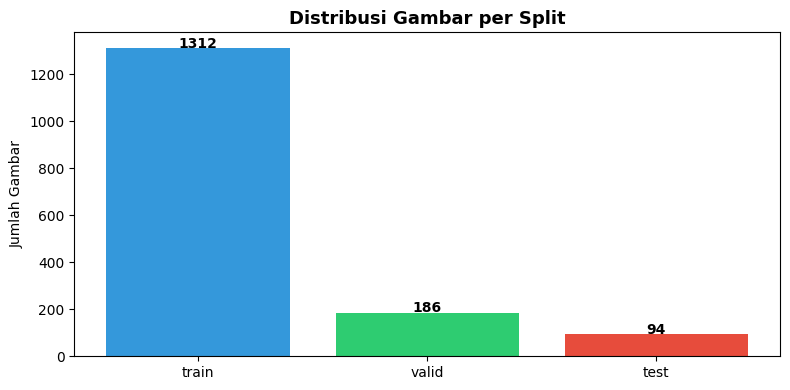

In [5]:
import matplotlib.pyplot as plt

# Hitung distribusi gambar per split per kelas
print("=" * 60)
print("📁  Distribusi Dataset")
print("=" * 60)

total_per_split = {}
for split in SPLITS:
    split_dir = DATASET_PATH / split
    total = 0
    print(f"\n📂 {split.upper()}")
    for cls_name in CLASS_NAMES:
        cls_dir = split_dir / cls_name
        if cls_dir.exists():
            count = len([f for f in cls_dir.iterdir()
                         if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
            print(f"   {cls_name:40s}: {count:4d} gambar")
            total += count
        else:
            print(f"   {cls_name:40s}: (tidak ada)")
    total_per_split[split] = total
    print(f"   {'TOTAL':40s}: {total:4d} gambar")

print("\n" + "=" * 60)
print(f"📊 Total keseluruhan: {sum(total_per_split.values())} gambar")

# Bar chart distribusi
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(total_per_split.keys(), total_per_split.values(),
       color=['#3498DB', '#2ECC71', '#E74C3C'][:len(total_per_split)])
ax.set_title('Distribusi Gambar per Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
for i, (k, v) in enumerate(total_per_split.items()):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.


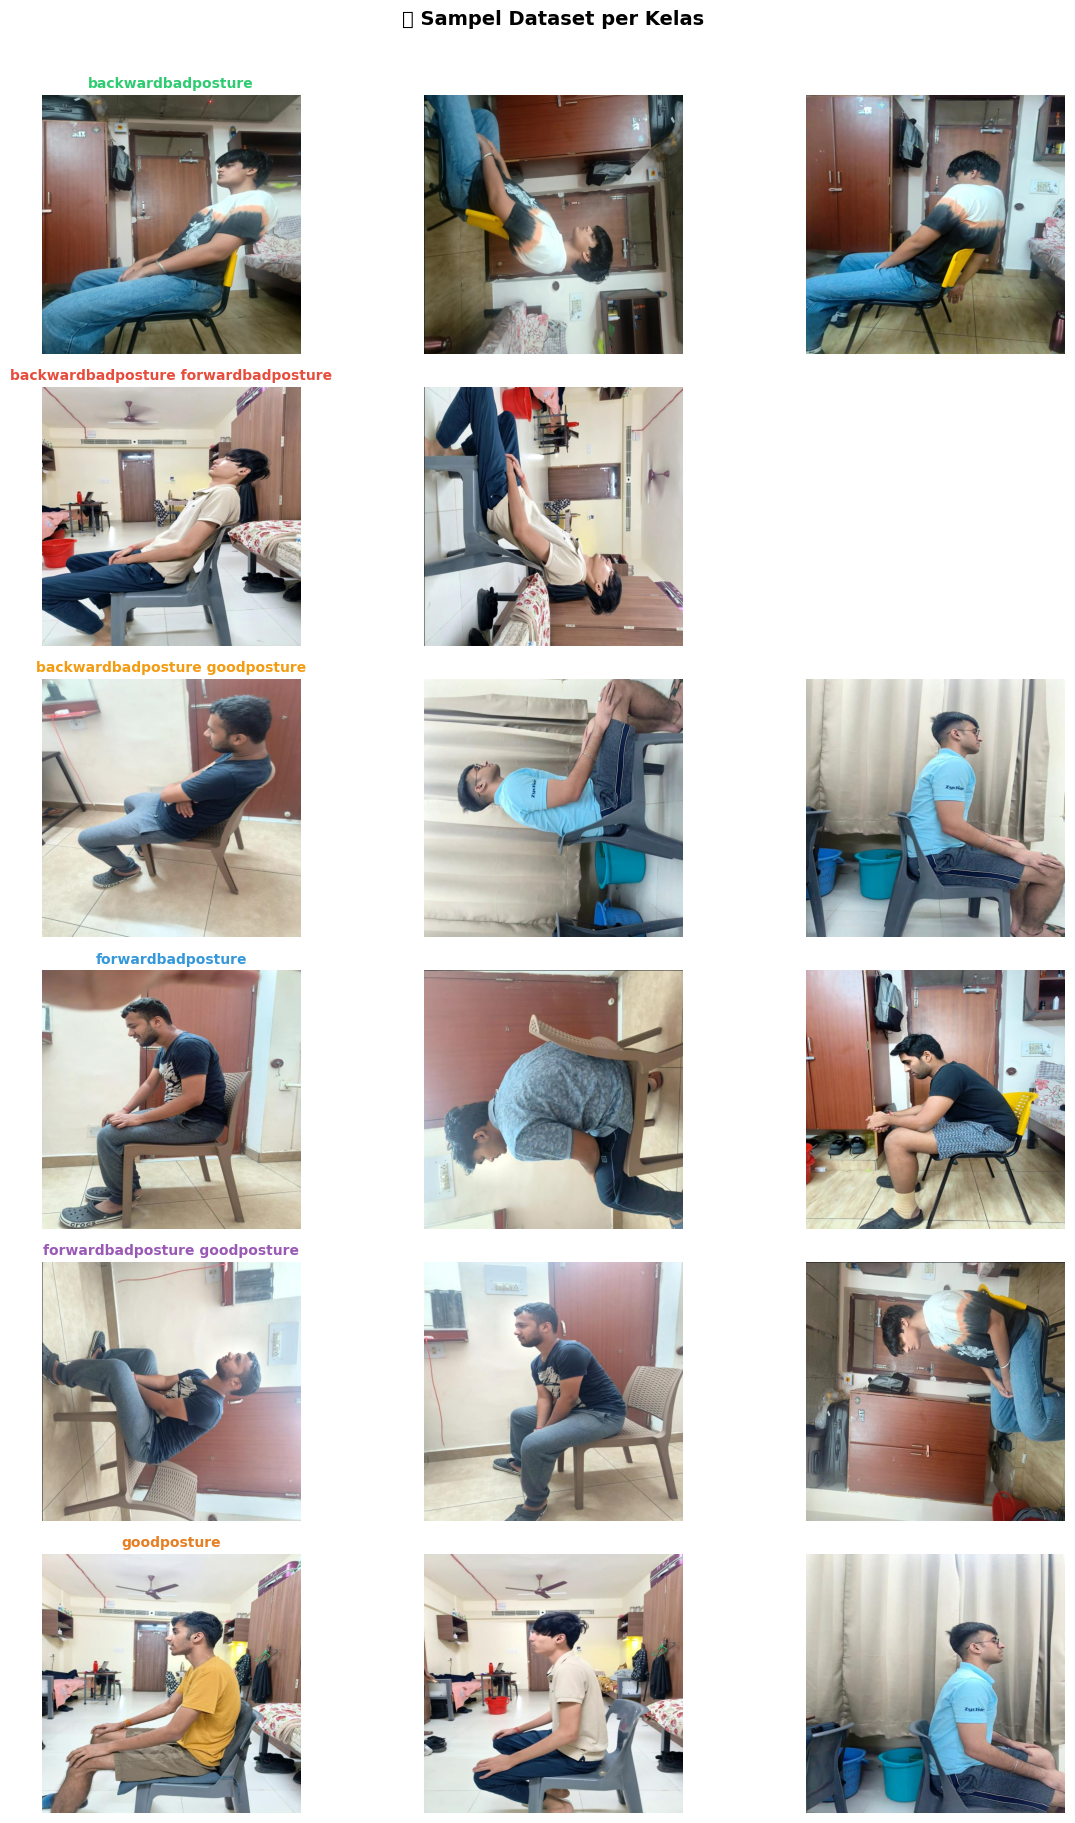

In [6]:
import random
from PIL import Image

# Visualisasi sampel gambar dari setiap kelas
n_classes = len(CLASS_NAMES)
samples_per_class = 3

fig, axes = plt.subplots(n_classes, samples_per_class,
                          figsize=(samples_per_class * 4, n_classes * 3))

# Handle kasus hanya 1 kelas
if n_classes == 1:
    axes = [axes]
elif n_classes > 1 and samples_per_class == 1:
    axes = [[ax] for ax in axes]

COLORS = ['#2ECC71', '#E74C3C', '#F39C12', '#3498DB', '#9B59B6',
          '#E67E22', '#1ABC9C', '#8E44AD']

for row, cls_name in enumerate(CLASS_NAMES):
    cls_dir = DATASET_PATH / 'train' / cls_name
    all_imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.jpeg'))
    samples = random.sample(all_imgs, min(samples_per_class, len(all_imgs)))
    color = COLORS[row % len(COLORS)]

    for col in range(samples_per_class):
        ax = axes[row][col] if n_classes > 1 else axes[col]
        if col < len(samples):
            img = Image.open(samples[col])
            ax.imshow(img)
            ax.set_xlabel(samples[col].name[:20], fontsize=7)
        else:
            ax.set_visible(False)
        ax.axis('off')
        if col == 0:
            ax.set_title(cls_name, fontsize=10, fontweight='bold', color=color, pad=5)

plt.suptitle('📸 Sampel Dataset per Kelas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 🗂️ Step 3.5 — Preprocessing: Kelompokkan Kelas → 2 Label

Dataset asli punya banyak subfolder kelas. Di sini kita:
1. **Hapus** folder `unlabeled`
2. **Gabungkan** semua kelas postur baik → `goodposture`
3. **Gabungkan** semua kelas postur buruk → `badposture`

Hasil akhir setiap split (`train`, `valid`, `test`) hanya punya 2 folder:
```
train/
├── goodposture/
└── badposture/
```


In [7]:
import shutil
from pathlib import Path

# ──────────────────────────────────────────────────────────────────
# Keyword untuk auto-assign ke goodposture / badposture
# Tambah keyword jika nama kelas di dataset kamu berbeda
# ──────────────────────────────────────────────────────────────────
GOOD_KEYWORDS = ['good', 'correct', 'proper', 'normal', 'benar', 'baik']
BAD_KEYWORDS  = ['bad', 'incorrect', 'wrong', 'slouch', 'hunch', 'lean',
                 'forward', 'backward', 'left', 'right', 'buruk', 'salah']

# Output: dataset baru dengan 2 kelas
DATASET_2CLASS = DATASET_PATH.parent / (DATASET_PATH.name + "_2class")

print(f"📂 Source dataset : {DATASET_PATH}")
print(f"📂 Output dataset : {DATASET_2CLASS}")
print()

summary = {}

for split in SPLITS:
    split_src = DATASET_PATH / split
    split_dst = DATASET_2CLASS / split

    good_dst = split_dst / "goodposture"
    bad_dst  = split_dst / "badposture"
    good_dst.mkdir(parents=True, exist_ok=True)
    bad_dst.mkdir(parents=True, exist_ok=True)

    count_good = count_bad = count_skip = 0

    for cls_dir in sorted(split_src.iterdir()):
        if not cls_dir.is_dir():
            continue

        cls_name = cls_dir.name.lower()

        # Hapus unlabeled
        if 'unlabeled' in cls_name:
            print(f"  🗑️  [{split}] Skip (unlabeled) : {cls_dir.name}")
            count_skip += len(list(cls_dir.glob('*.*')))
            continue

        # Tentukan kategori
        if any(k in cls_name for k in GOOD_KEYWORDS):
            dst = good_dst
            label = "goodposture"
        elif any(k in cls_name for k in BAD_KEYWORDS):
            dst = bad_dst
            label = "badposture"
        else:
            # Kelas tidak dikenali — tanya user
            print(f"  ❓ [{split}] Tidak dikenali: '{cls_dir.name}'")
            choice = input(f"     Masukkan ke [g]oodposture / [b]adposture / [s]kip? ").strip().lower()
            if choice == 'g':
                dst, label = good_dst, "goodposture"
            elif choice == 'b':
                dst, label = bad_dst, "badposture"
            else:
                print(f"     ⏭️  Di-skip")
                count_skip += len(list(cls_dir.glob('*.*')))
                continue

        # Copy semua gambar, rename agar tidak bentrok antar kelas
        imgs = [f for f in cls_dir.iterdir()
                if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
        for img in imgs:
            new_name = f"{cls_dir.name}_{img.name}"
            shutil.copy2(img, dst / new_name)

        moved = len(imgs)
        if label == "goodposture":
            count_good += moved
        else:
            count_bad += moved

        print(f"  ✅ [{split}] {cls_dir.name:35s} → {label} ({moved} gambar)")

    summary[split] = {'good': count_good, 'bad': count_bad, 'skip': count_skip}

# Update variabel global
DATASET_PATH = DATASET_2CLASS
CLASS_NAMES = ['badposture', 'goodposture']
SPLITS       = [s for s in ['train', 'valid', 'test'] if (DATASET_PATH / s).exists()]

print()
print("=" * 60)
print("📊 Ringkasan Preprocessing")
print("=" * 60)
print(f"{'Split':>8} | {'goodposture':>12} | {'badposture':>10} | {'skipped':>8}")
print("-" * 48)
for split, cnt in summary.items():
    print(f"{split:>8} | {cnt['good']:>12} | {cnt['bad']:>10} | {cnt['skip']:>8}")

print()
print(f"✅ Dataset 2-kelas siap di: {DATASET_PATH}")
print(f"   Kelas: {CLASS_NAMES}")


📂 Source dataset : /content/Sitting-Posture-1
📂 Output dataset : /content/Sitting-Posture-1_2class

  🗑️  [train] Skip (unlabeled) : Unlabeled
  ✅ [train] backwardbadposture                  → badposture (354 gambar)
  ✅ [train] backwardbadposture forwardbadposture → badposture (2 gambar)
  ✅ [train] backwardbadposture goodposture      → goodposture (4 gambar)
  ✅ [train] forwardbadposture                   → badposture (268 gambar)
  ✅ [train] forwardbadposture goodposture       → goodposture (4 gambar)
  ✅ [train] goodposture                         → goodposture (680 gambar)
  🗑️  [valid] Skip (unlabeled) : Unlabeled
  ✅ [valid] backwardbadposture                  → badposture (45 gambar)
  ✅ [valid] backwardbadposture goodposture      → goodposture (2 gambar)
  ✅ [valid] forwardbadposture                   → badposture (41 gambar)
  ✅ [valid] goodposture                         → goodposture (98 gambar)
  ✅ [test] backwardbadposture                  → badposture (29 gambar)
  ✅ [te

## 🏋️ Step 4 — Training YOLO



>💡 **YOLO26** adalah versi terbaru (2026) dari Ultralytics — lebih akurat & efisien dari YOLO12.
> Untuk task **classification** (bukan detection), gunakan suffix **`-cls`**.


In [8]:
from ultralytics import YOLO
import torch

# ──────────────────────────────────────────────────────────────────
# Konfigurasi Training — ubah sesuai kebutuhan
# ──────────────────────────────────────────────────────────────────
MODEL_NAME  = "yolo26s-cls.pt"   # Ganti: yolo11n-cls / yolo11m-cls / yolov8s-cls
EPOCHS      = 100                  # Epoch training (naikan ke 100 untuk akurasi lebih tinggi)
IMG_SIZE    = 224                 # Ukuran input gambar (224 atau 320)
BATCH_SIZE  = 32                  # Batch size (kurangi jika VRAM tidak cukup)
PROJECT     = "runs/classify"     # Folder output
RUN_NAME    = "posture_v1"        # Nama run ini
PATIENCE    = 10                  # Early stopping patience

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"🔧 Model    : {MODEL_NAME}")
print(f"🔧 Device   : {DEVICE}")
print(f"🔧 Epochs   : {EPOCHS}")
print(f"🔧 Img size : {IMG_SIZE}px")
print(f"🔧 Batch    : {BATCH_SIZE}")
print(f"\n▶️  Memulai training...")

# Load pretrained model (download otomatis jika belum ada)
model = YOLO(MODEL_NAME)

# Training
results = model.train(
    data    = str(DATASET_PATH),   # Path ke folder dataset (berisi train/valid/test)
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    project = PROJECT,
    name    = RUN_NAME,
    device  = DEVICE,
    patience= PATIENCE,
    save    = True,
    plots   = True,
    verbose = True,
)

print(f"\n✅ Training selesai!")
print(f"📁 Hasil tersimpan di: {PROJECT}/{RUN_NAME}")


🔧 Model    : yolo26s-cls.pt
🔧 Device   : 0
🔧 Epochs   : 100
🔧 Img size : 224px
🔧 Batch    : 32

▶️  Memulai training...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Sitting-Posture-1_2class, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0

## 📊 Step 5 — Evaluasi Model

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

run_dir = Path('/content/runs/classify/runs/classify/posture_v1-2/')

# Plot training curves yang tersedia
plots = [
    (run_dir / 'results.png', '📈 Training Curves'),
    (run_dir / 'confusion_matrix.png', '🔢 Confusion Matrix'),
    (run_dir / 'confusion_matrix_normalized.png', '🔢 Confusion Matrix (Normalized)'),
    (run_dir / 'val_batch0_pred.jpg', '🖼️ Prediksi Validation Batch'),
]

for path, title in plots:
    if path.exists():
        fig, ax = plt.subplots(figsize=(14, 7))

        img = mpimg.imread(path)

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

    else:
        print(f"⚠️ File tidak ditemukan: {path}")

⚠️ File tidak ditemukan: /content/runs/classify/runs/classify/posture_v1-2/results.png
⚠️ File tidak ditemukan: /content/runs/classify/runs/classify/posture_v1-2/confusion_matrix.png
⚠️ File tidak ditemukan: /content/runs/classify/runs/classify/posture_v1-2/confusion_matrix_normalized.png
⚠️ File tidak ditemukan: /content/runs/classify/runs/classify/posture_v1-2/val_batch0_pred.jpg


In [11]:
# Evaluasi model terbaik pada validation set
best_model_path = '/content/runs/classify/runs/classify/posture_v1/weights/best.pt'
best_model = YOLO(str(best_model_path))

print("🔍 Mengevaluasi model terbaik pada validation set...")
val_results = best_model.val(
    data   = str(DATASET_PATH),
    imgsz  = IMG_SIZE,
    device = DEVICE,
    split  = 'val',      # gunakan split validasi
)

# Untuk classification task, metric ada di val_results.top1 dan top5
print("\n" + "=" * 50)
print("📊  Hasil Evaluasi (Classification)")
print("=" * 50)
print(f"  Top-1 Accuracy : {val_results.top1:.4f}  ({val_results.top1*100:.2f}%)")
print(f"  Top-5 Accuracy : {val_results.top5:.4f}  ({val_results.top5*100:.2f}%)")


🔍 Mengevaluasi model terbaik pada validation set...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: /content/Sitting-Posture-1_2class/train... found 1312 images in 2 classes ✅ 
val: /content/Sitting-Posture-1_2class/valid... found 186 images in 2 classes ✅ 
test: /content/Sitting-Posture-1_2class/test... found 94 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1075.7±261.1 MB/s, size: 45.6 KB)
val: Scanning /content/Sitting-Posture-1_2class/valid... 186 images, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 52.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 12/12 5.9it/s 2.0s
                   all      0.968          1
Speed: 0.5ms preprocess, 3.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

📊  Hasil Evaluasi (Classification)
  Top-1 Accuracy : 0.9677  (96.77%)
  

## 🚨 Step 6 — Sistem Peringatan Postur Duduk

Di bagian ini kita membuat fungsi `analyze_posture()` yang:
- Mendeteksi postur dalam gambar menggunakan YOLO classification
- Mengklasifikasikan postur sebagai **benar** atau **tidak benar**
- Mengeluarkan **WARNING** jika postur buruk terdeteksi
- Menampilkan overlay visual dengan status


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────
# Auto-detect kelas BAIK dan BURUK berdasarkan nama kelas
# ──────────────────────────────────────────────────────────────────
BAD_POSTURE_CLASSES  = []
GOOD_POSTURE_CLASSES = []

GOOD_KEYWORDS = ['good', 'correct', 'proper', 'normal', 'benar', 'baik']
BAD_KEYWORDS  = ['bad', 'incorrect', 'wrong', 'slouch', 'hunch', 'lean',
                 'forward', 'backward', 'left', 'right', 'buruk', 'salah']

for i, name in enumerate(CLASS_NAMES):
    name_lower = name.lower()
    if any(k in name_lower for k in GOOD_KEYWORDS):
        GOOD_POSTURE_CLASSES.append(i)
    elif any(k in name_lower for k in BAD_KEYWORDS):
        BAD_POSTURE_CLASSES.append(i)
    else:
        # Default: index 0 = baik, sisanya = buruk
        (GOOD_POSTURE_CLASSES if i == 0 else BAD_POSTURE_CLASSES).append(i)

print("=" * 50)
print("⚙️  Konfigurasi Sistem Warning")
print("=" * 50)
print(f"  Semua kelas  : {CLASS_NAMES}")
print(f"  Postur BAIK  : {[CLASS_NAMES[i] for i in GOOD_POSTURE_CLASSES]}")
print(f"  Postur BURUK : {[CLASS_NAMES[i] for i in BAD_POSTURE_CLASSES]}")
print()
print("💡 Jika hasil auto-detect salah, edit manual, contoh:")
print("   BAD_POSTURE_CLASSES  = [1, 2, 3]")
print("   GOOD_POSTURE_CLASSES = [0]")


⚙️  Konfigurasi Sistem Warning
  Semua kelas  : ['badposture', 'goodposture']
  Postur BAIK  : ['goodposture']
  Postur BURUK : ['badposture']

💡 Jika hasil auto-detect salah, edit manual, contoh:
   BAD_POSTURE_CLASSES  = [1, 2, 3]
   GOOD_POSTURE_CLASSES = [0]


In [13]:
def analyze_posture(image_input, model, conf_threshold=0.35, show_plot=True):
    """
    Menganalisis postur duduk dan memberikan warning jika postur buruk.

    Args:
        image_input   : str/Path ke gambar, atau np.ndarray (BGR)
        model         : YOLO model yang sudah diload
        conf_threshold: Minimum confidence score
        show_plot     : Tampilkan visualisasi hasil

    Returns:
        dict: {
            'status'    : 'GOOD' | 'WARNING' | 'NO_DETECTION',
            'class_name': nama kelas dengan confidence tertinggi,
            'confidence': confidence tertinggi,
            'message'   : pesan warning/status
        }
    """
    # Load gambar
    if isinstance(image_input, (str, Path)):
        img_bgr = cv2.imread(str(image_input))
        if img_bgr is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {image_input}")
    elif isinstance(image_input, np.ndarray):
        img_bgr = image_input.copy()
    else:
        raise ValueError("image_input harus path string atau numpy array (BGR)")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_bgr.shape[:2]

    # Inferensi (classification)
    pred    = model.predict(img_rgb, imgsz=IMG_SIZE, verbose=False)[0]
    probs   = pred.probs  # Probs object untuk classification

    if probs is None or len(probs.data) == 0:
        status, message = 'NO_DETECTION', '⚪ Tidak ada prediksi'
        overlay_color   = (128, 128, 128)
        top_class, top_conf = 'N/A', 0.0
    else:
        top_idx   = int(probs.top1)
        top_conf  = float(probs.top1conf.item())
        top_class = CLASS_NAMES[top_idx] if top_idx < len(CLASS_NAMES) else f"cls_{top_idx}"

        if top_conf < conf_threshold:
            status, message = 'NO_DETECTION', f'⚪ Confidence rendah ({top_conf:.0%})'
            overlay_color   = (128, 128, 128)
        elif top_idx in BAD_POSTURE_CLASSES:
            status  = 'WARNING'
            message = f'🚨 PERINGATAN! Postur buruk: {top_class} ({top_conf:.0%})'
            overlay_color = (220, 53, 69)
        else:
            status  = 'GOOD'
            message = f'✅ Postur BAIK: {top_class} ({top_conf:.0%})'
            overlay_color = (40, 167, 69)

    # Visualisasi
    if show_plot:
        vis = img_rgb.copy()

        # Panel status
        panel_h = 70
        panel   = np.full((panel_h, W, 3), overlay_color, dtype=np.uint8)
        cv2.putText(panel, message, (15, 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)
        combined = np.vstack([panel, vis])

        # Border warna status
        border_color = tuple(overlay_color)
        cv2.rectangle(combined, (0, 0),
                      (combined.shape[1]-1, combined.shape[0]-1), border_color, 8)

        # Top-5 probabilities bar
        if probs is not None:
            top5_idx  = probs.top5
            top5_conf = probs.top5conf.tolist()
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                            gridspec_kw={'width_ratios': [2, 1]})
            ax1.imshow(combined)
            ax1.axis('off')

            bar_colors = ['#dc3545' if i in BAD_POSTURE_CLASSES else '#28a745'
                          for i in top5_idx]
            names5 = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"cls_{i}"
                      for i in top5_idx]
            bars = ax2.barh(names5, [c*100 for c in top5_conf], color=bar_colors)
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title('Top-5 Probabilitas', fontweight='bold')
            ax2.set_xlim(0, 100)
            for bar, conf in zip(bars, top5_conf):
                ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{conf:.1%}', va='center', fontsize=9)
        else:
            fig, ax1 = plt.subplots(figsize=(8, 6))
            ax1.imshow(combined)
            ax1.axis('off')

        title_color = '#dc3545' if status == 'WARNING' else ('#28a745' if status == 'GOOD' else '#6c757d')
        plt.suptitle(message, fontsize=13, fontweight='bold', color=title_color)
        plt.tight_layout()
        plt.show()

    return {
        'status'     : status,
        'class_name' : top_class,
        'confidence' : top_conf,
        'message'    : message,
    }

print("✅ Fungsi analyze_posture() siap digunakan!")


✅ Fungsi analyze_posture() siap digunakan!


🔍 Menganalisis 4 gambar dari validation set...



Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.


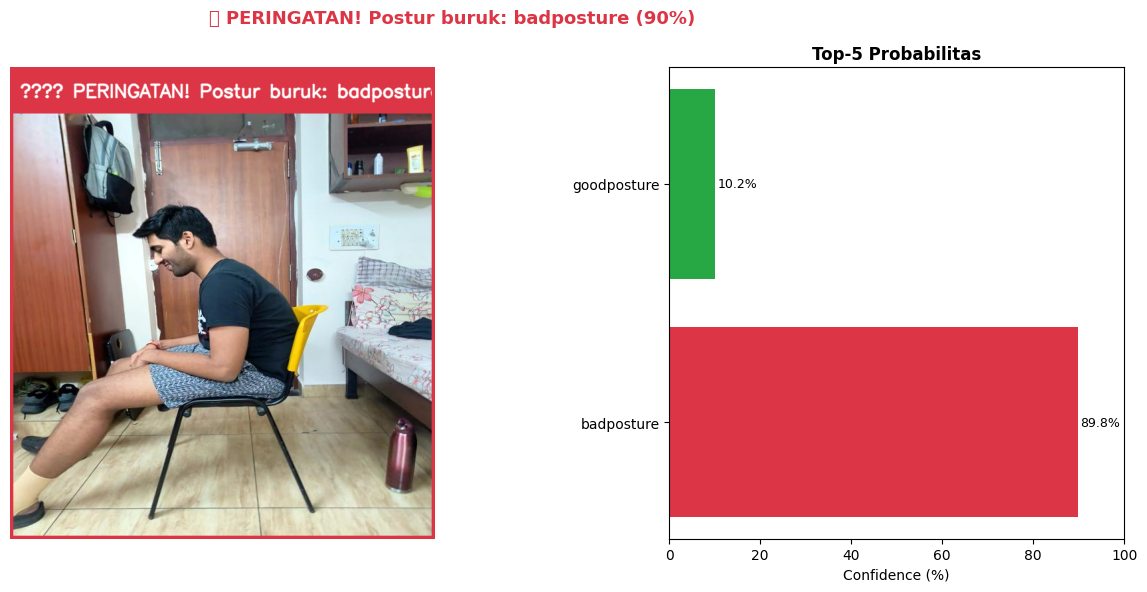

  📁 forwardbadposture_forward_lean_bad_posture-80-_jpg.rf.9287ac37b27c22ba48c3f05d555a94d5.jpg
     Status     : WARNING
     Kelas      : badposture
     Confidence : 89.84%



Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.


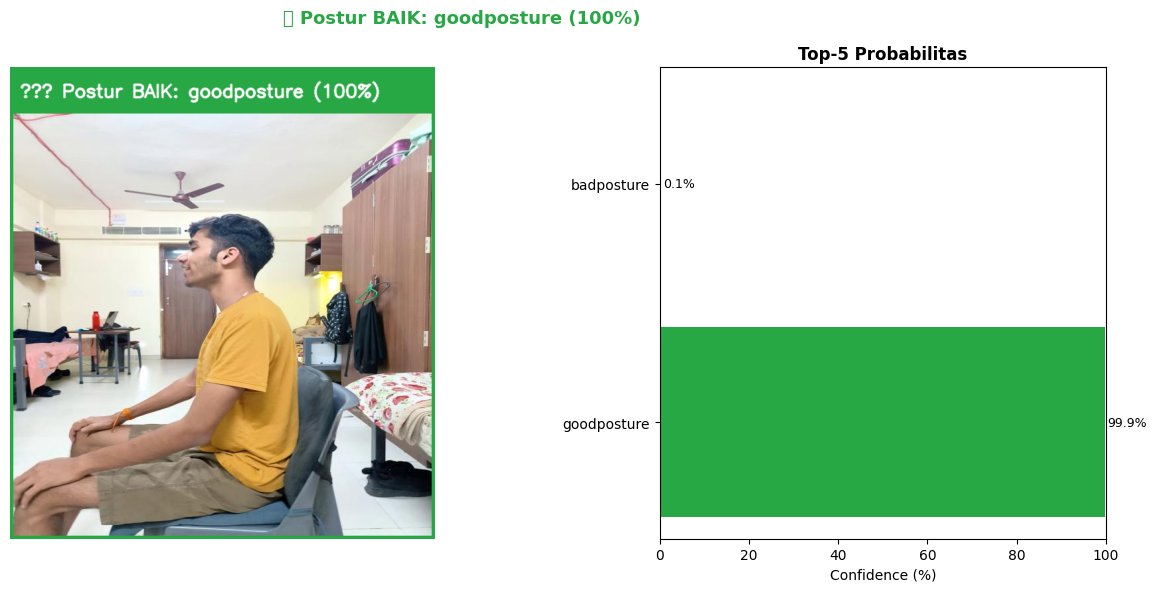

  📁 goodposture_good_posture-348-_jpg.rf.ce263109a2e88e51ead70066683070a4.jpg
     Status     : GOOD
     Kelas      : goodposture
     Confidence : 99.89%



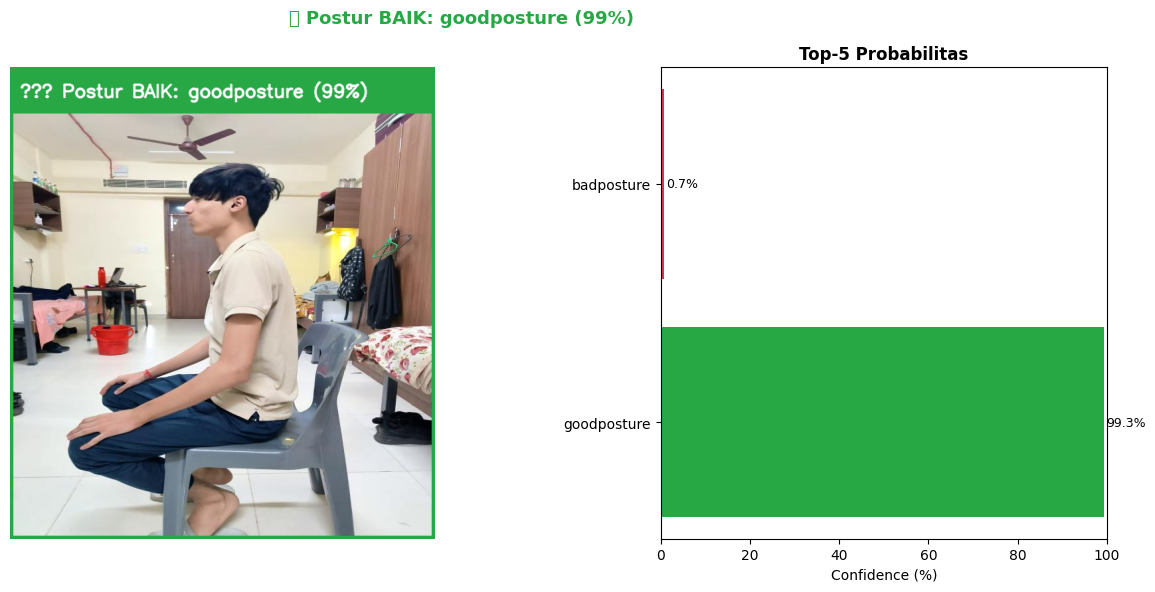

  📁 goodposture_good_posture-369-_jpg.rf.e5543f3f11e5a8076c17a2c3fab3248f.jpg
     Status     : GOOD
     Kelas      : goodposture
     Confidence : 99.32%



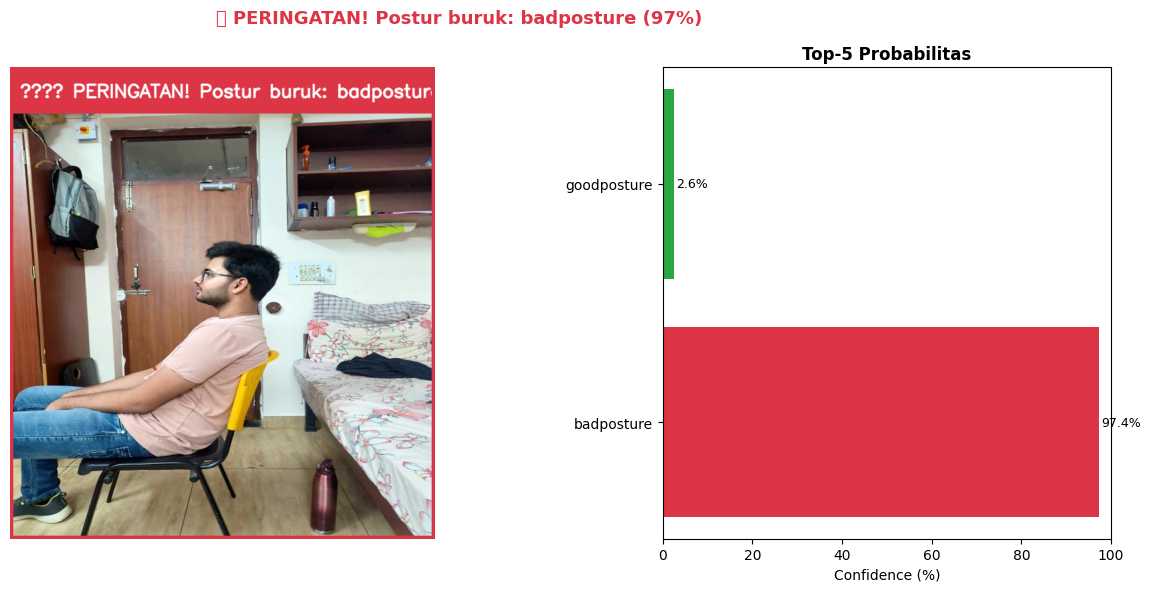

  📁 backwardbadposture_backward_lean_bad_posture-55-_jpg.rf.3806c7aaf101a7022347c0c0d2f2e9ed.jpg
     Status     : WARNING
     Kelas      : badposture
     Confidence : 97.42%



In [15]:
# ── Uji pada gambar validasi ──────────────────────────────────────
valid_img_dir = DATASET_PATH / "valid"
# Untuk classification, gambar ada di subfolder kelas
test_images = []
for cls_name in CLASS_NAMES:
    cls_dir = valid_img_dir / cls_name
    if cls_dir.exists():
        test_images += list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))

if test_images:
    sample_imgs = random.sample(test_images, min(4, len(test_images)))
    print(f"🔍 Menganalisis {len(sample_imgs)} gambar dari validation set...\n")
    for img_path in sample_imgs:
        result = analyze_posture(img_path, best_model, conf_threshold=0.5)
        print(f"  📁 {img_path.name}")
        print(f"     Status     : {result['status']}")
        print(f"     Kelas      : {result['class_name']}")
        print(f"     Confidence : {result['confidence']:.2%}")
        print()
else:
    print("⚠️  Tidak ada gambar di folder valid/")


## 📷 Step 7 — Uji dengan Gambar Kustom

In [ ]:
# ── Upload & analisis gambar kustom ───────────────────────────────
from google.colab import files

print("📤 Upload gambar postur duduk Anda:")
uploaded = files.upload()

for filename, content in uploaded.items():
    print(f"\n🔍 Menganalisis: {filename}")
    img_array = np.frombuffer(content, dtype=np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    result    = analyze_posture(img_bgr, best_model, conf_threshold=0.3)
    print(f"   ➜  {result['message']}")
    if result['status'] == 'WARNING':
        print("   ⚠️  Perbaiki postur duduk Anda untuk kesehatan yang lebih baik!")
    elif result['status'] == 'GOOD':
        print("   👍  Pertahankan postur duduk yang baik ini!")


## 📋 Step 10 — Ringkasan & Cara Penggunaan Model

```python
# ── Cara menggunakan model yang sudah ditraining ──────────────────
from ultralytics import YOLO
import cv2

# Load model
model = YOLO('best.pt')

# Prediksi pada 1 gambar
results = model.predict('foto_postur.jpg', conf=0.35)
for r in results:
    top_cls  = r.probs.top1
    top_conf = float(r.probs.top1conf)
    print(f"Kelas: {model.names[top_cls]}, Confidence: {top_conf:.2%}")

# Prediksi real-time dari webcam (jalankan di lokal, bukan Colab)
cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret: break
    results   = model.predict(frame, imgsz=224, verbose=False)
    top_cls   = results[0].probs.top1
    top_conf  = float(results[0].probs.top1conf)
    cls_name  = model.names[top_cls]
    color     = (0, 200, 0) if 'good' in cls_name.lower() else (0, 0, 220)
    label     = f"{cls_name} {top_conf:.0%}"
    cv2.putText(frame, label, (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    cv2.imshow('Posture Monitor', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
```

---
### 🔗 Referensi
- Dataset: https://universe.roboflow.com/dataset-sqm0h/sitting-posture-ezkda
- Ultralytics YOLO11 Docs: https://docs.ultralytics.com
- YOLO26 Release: https://docs.ultralytics.com/models/yolo26/
- Roboflow API: https://docs.roboflow.com


In [18]:
!zip -r posture_v1.zip "/content/runs/classify/runs/classify/posture_v1"

  adding: content/runs/classify/runs/classify/posture_v1/ (stored 0%)
  adding: content/runs/classify/runs/classify/posture_v1/val_batch0_labels.jpg (deflated 0%)
  adding: content/runs/classify/runs/classify/posture_v1/val_batch2_pred.jpg (deflated 0%)
  adding: content/runs/classify/runs/classify/posture_v1/val_batch1_pred.jpg (deflated 0%)
  adding: content/runs/classify/runs/classify/posture_v1/weights/ (stored 0%)
  adding: content/runs/classify/runs/classify/posture_v1/weights/last.pt (deflated 8%)
  adding: content/runs/classify/runs/classify/posture_v1/weights/best.pt (deflated 8%)
  adding: content/runs/classify/runs/classify/posture_v1/val_batch1_labels.jpg (deflated 0%)
  adding: content/runs/classify/runs/classify/posture_v1/train_batch1.jpg (deflated 2%)
  adding: content/runs/classify/runs/classify/posture_v1/args.yaml (deflated 52%)
  adding: content/runs/classify/runs/classify/posture_v1/confusion_matrix_normalized.png (deflated 30%)
  adding: content/runs/classify/runs

In [19]:
from google.colab import files

files.download('posture_v1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>